# Figure 7

In [ ]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.decomposition import PCA
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d.art3d import Line3DCollection

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


## Figure 7
Ghost structures in GRN network

**Figure 7a**, bifurcation diagram for a single gene with positive auto-regulation

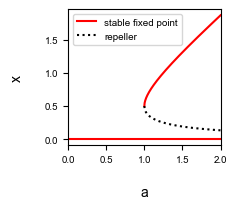

In [6]:
fig = plt.figure(figsize=(5*inCm,4.5*inCm))

ax = fig.add_subplot()

K = 0.5

a_range0 = np.linspace(0,2,100)
a_range1 = np.linspace(4*K**2,2,500)

sol0 = a_range0*0
sol1 = a_range1/2 + np.sqrt(a_range1**2/4 - K**2)
sol2 = a_range1/2 - np.sqrt(a_range1**2/4 - K**2)

ax.plot(a_range0,sol0,'-r',label='stable fixed point')
ax.plot(a_range1,sol1,'-r')
ax.plot(a_range1,sol2,':k',label='repeller')

ax.set_ylabel("x")
ax.set_xlabel("a")
ax.set_xlim(0,2)
ax.legend(fontsize=7)
plt.savefig("Figure7a.svg")

**Figure 7b**, GRN with n=12 nodes 

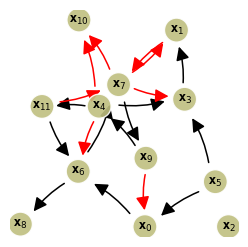

In [7]:
n = 12
seed = 135   

rng = np.random.default_rng(seed)
np.random.seed(seed)

G = nx.erdos_renyi_graph(n,0.15,directed=True,seed=seed)
A = nx.to_numpy_array(G)

p_inhibitory = 0.5
# introduce inhibitory links
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if A[i, j] == 1:
            if rng.random() < p_inhibitory:
                A[i, j] = -1


node_colors = [(0.75, 0.75, 0.5, 0.8)] * n
node_labels = [f"x$_{{{i}}}$" for i in range(n)]

plt.figure(figsize=(7.5*inCm,7.5*inCm))
gid.draw_network(A, node_colors, node_labels, layout="neato",node_size=300,label_font_size=9,graphviz_args=f"-Gepsilon=.00001 -Goverlap=false -Gstart=7 -splines=true")
plt.axis("off")
plt.savefig("Figure7b.svg")

**Figure 7c**, Identified ghost structures embedded in the dynamics of GRN from Figure 7b

[ghostID_phaseSpaceSample] Running with threads (11 workers)


Processing ICs: 100%|██████████| 300/300 [16:03<00:00,  3.21s/IC]
C:\Users\dkoch\AppData\Local\Temp\ipykernel_8364\3000342479.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('spring_r', maxDim+1)


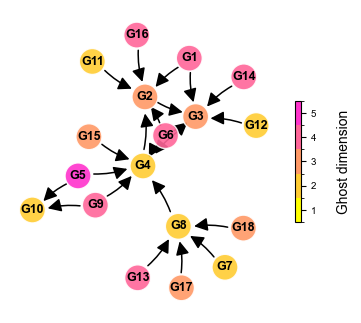

In [ ]:
# Run ghostID on phase space samples
parameters_GRN_net = [0.998,0.25,0.5,0.5,0.5,A]
dt = 0.1
t_end = 800
timesteps = np.linspace(0,t_end,int(t_end/dt))

result_pss = gid.ghostID_phaseSpaceSample(mod.GRN_net,parameters_GRN_net,0,t_end,dt,
                                        [np.linspace(0,1,10) for i in range(n)],n_samples=300,evLimit=0,seed=10, #seed=10, evLimit=0.03 #samples:30/300
                                        peak_kwargs={"prominence":2,"width":50*dt},display_warnings=False,epsilon_gid=0.015,eigval_NN_sorting=True,epsilon_SN_ghosts=0.5,epsilon_unify=0.75)

# Save results with pickle
with open('result_pss.pkl', 'wb') as f:
    pickle.dump(result_pss, f) 

C:\Users\dkoch\AppData\Local\Temp\ipykernel_8364\653462348.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('spring_r', maxDim+1)


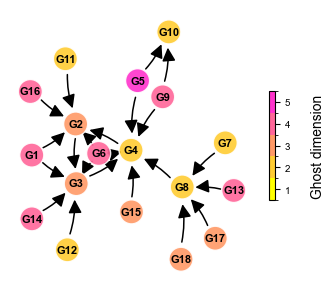

In [40]:
with open('result_pss.pkl', 'rb') as f:
    result_pss = pickle.load(f)

M, M_labels = gid.ghost_connections(result_pss)
unique_ghosts = gid.unique_ghosts(result_pss)

dimensions = [g["dimension"] for g in unique_ghosts]
maxDim = max(dimensions)


# plt.figure(figsize=(15*inCm,15*inCm))
cmap = plt.cm.get_cmap('spring_r', maxDim+1)
nodeColors = [cmap(dim-1) for dim in dimensions]
plt.figure(figsize=(10*inCm,9*inCm))
# plt.figure(figsize=(11*inCm,10*inCm))
gid.draw_network(M, nodeColors, M_labels, layout="neato",node_size=300,label_font_size=8,graphviz_args=f"-Gepsilon=.000001 -Goverlap=true -Gstart=9 -splines=true") #Gstart 2
boundaries = np.arange(maxDim + 1) - 0.5
norm = mcolors.BoundaryNorm(boundaries, ncolors=maxDim)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', shrink=0.4)
cbar.set_ticks(np.arange(maxDim))
cbar.set_ticklabels([f'{i+1}' for i in range(maxDim)])
cbar.set_label('Ghost dimension')
plt.axis("off")
plt.gca().margins(0.1)
plt.savefig("Figure7c.svg")

**Figure 7d**, Example time-courses of GRN from Figure 7b

In [108]:
def deterministic_sphere_sampling(P, n_samples, n_radial, r):
    """
    Deterministically sample points in an N-dimensional ball centered at P.

    Parameters
    ----------
    P : array_like, shape (N,)
        Center point
    n_samples : int
        Total number of sample points
    r : float
        Maximum radius

    Returns
    -------
    X0 : list of ndarray
        List of initial conditions
    """
    P = np.asarray(P)
    N = P.size

    # Number of radial shells (heuristic)
    # n_radial = int(np.sqrt(n_samples))
    # n_radial = max(1, n_radial)
    n_dirs = n_samples // n_radial

    # Deterministic directions via evenly spaced angles in index space
    dirs = []
    for i in range(n_dirs):
        v = np.array([np.cos((i+1)*(j+1)) for j in range(N)])
        v /= np.linalg.norm(v)
        dirs.append(v)

    # Deterministic radii
    radii = np.linspace(0.2*r, r, n_radial)

    X0 = []
    for rho in radii:
        for v in dirs:
            X0.append(P + rho * v)
            if len(X0) >= n_samples:
                return X0

    return X0

parameters_GRN_net = [0.998,0.25,0.5,0.5,0.5,A]
dt = 0.2
t_end = 100
timesteps = np.linspace(0,t_end,int(t_end/dt))


# -----------------------------
# Sample initial conditions
# -----------------------------
ghostNr = 8
P = unique_ghosts[ghostNr]["position"]
N = 12
k = 100
delta = 0.25

# rng = np.random.default_rng(1)
# directions = rng.normal(size=(k, N))
# directions /= np.linalg.norm(directions, axis=1)[:, None]
# radii = rng.uniform(0, delta, size=k)
# X0 = P + directions * radii[:, None]
X0 = deterministic_sphere_sampling(P, k, 3, delta)

# -----------------------------
# Simulate trajectories
# -----------------------------

trajectories = []

for x0 in X0:
    sol = solve_ivp(mod.GRN_net, (0, t_end), x0,
                        t_eval=timesteps, args=(parameters_GRN_net,),method='RK45')
    trajectories.append(sol.y[:,::6].T)

# -----------------------------
# PCA
# -----------------------------
X_all = np.vstack(trajectories)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_all)

# Split trajectories back
idx = 0
traj_pca = []
for tr in trajectories:
    traj_pca.append(X_pca[idx:idx+len(tr)])
    idx += len(tr)

P_pca = pca.transform(P.reshape(1, -1))[0]



# # -----------------------------
# # Plot
# # -----------------------------

# from mpl_toolkits.mplot3d.art3d import Line3DCollection

# fig = plt.figure(figsize=(7*inCm,7*inCm))
# ax = fig.add_subplot(projection='3d')
# cmap = plt.cm.hot

# from matplotlib.colors import Normalize

# norm = Normalize(vmin=0.0, vmax=t_end)

# for tr in traj_pca:
#     # Build line segments
#     segments = np.stack([tr[:-1], tr[1:]], axis=1)
#     tcolor = np.linspace(0, t_end, len(segments))

#     lc = Line3DCollection(segments, cmap=cmap, norm=norm)
#     lc.set_array(tcolor)
#     lc.set_linewidth(2.0)
#     ax.add_collection3d(lc)

# from matplotlib.cm import ScalarMappable

# sm = ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# # cbar = plt.colorbar(sm, ax=ax, pad=0.05)
# cbar = fig.colorbar(
#     sm,
#     ax=ax,
#     pad=0.1,
#     shrink=0.5,
#     aspect=20
# )
# cbar.set_label("time (a.u.)", fontsize=7)
   
# # Plot P
# # ax.plot(*P_pca, color='deepskyblue', ms=120, label=unique_ghosts[6]["id"], zorder=0)
# ax.plot(P_pca[0],P_pca[1],P_pca[2],'o', color=nodeColors[ghostNr],mec='k', ms=8, label=unique_ghosts[ghostNr]["id"], zorder=k+1)

# fun.noBackground(ax)
# # ax.view_init(20,45)
# ax.view_init(40,90)

# ax.set_title(f"local flow near {unique_ghosts[ghostNr]["id"]} (dimension = {unique_ghosts[ghostNr]["dimension"]})",fontsize=8)
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")
# ax.legend(fontsize=7)
# plt.show()



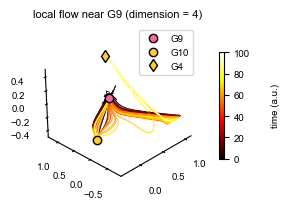

In [109]:
# -----------------------------
# Plot
# -----------------------------



fig = plt.figure(figsize=(7*inCm,7*inCm))
ax = fig.add_subplot(projection='3d')
cmap = plt.cm.hot

norm = Normalize(vmin=0.0, vmax=t_end)

for tr in traj_pca:
    # Build line segments
    segments = np.stack([tr[:-1], tr[1:]], axis=1)
    tcolor = np.linspace(0, t_end, len(segments))

    lc = Line3DCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(tcolor)
    lc.set_linewidth(0.6)
    ax.add_collection3d(lc)


sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# cbar = plt.colorbar(sm, ax=ax, pad=0.05)
cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.1,
    shrink=0.5,
    aspect=20
)
cbar.set_label("time (a.u.)", fontsize=7)
   
# Plot P
# ax.plot(*P_pca, color='deepskyblue', ms=120, label=unique_ghosts[6]["id"], zorder=0)
ax.plot(P_pca[0],P_pca[1],P_pca[2],'o', color=nodeColors[ghostNr],mec='k', ms=6, label=unique_ghosts[ghostNr]["id"], zorder=k+2)

P2 = unique_ghosts[9]["position"]
P2_pca = pca.transform(P2.reshape(1, -1))[0]
ax.plot(P2_pca[0],P2_pca[1],P2_pca[2],'o', color=nodeColors[9],mec='k', ms=6, label=unique_ghosts[9]["id"], zorder=k+1)


P3 = unique_ghosts[3]["position"]
P3_pca = pca.transform(P3.reshape(1, -1))[0]
ax.plot(P3_pca[0],P3_pca[1],P3_pca[2],'d', color=nodeColors[9],mec='k', ms=6, label=unique_ghosts[3]["id"], zorder=k+1)


fun.noBackground(ax)
# ax.view_init(45,315)
ax.view_init(29,224)

ax.set_title(f"local flow near {unique_ghosts[ghostNr]["id"]} (dimension = {unique_ghosts[ghostNr]["dimension"]})",fontsize=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(fontsize=7)
plt.savefig("Figure7e.svg")
plt.show()



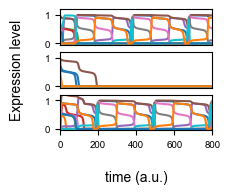

In [82]:
parameters_GRN_net = [0.998,0.25,0.5,0.5,0.5,A]
dt = 0.2
t_end=800
timesteps = np.linspace(0,t_end,int(t_end/dt))

np.random.seed(16)

fig = plt.figure(figsize=(5*inCm,4*inCm))
for i in range(3):
    plt.subplot(3,1,3-i)
    ic = np.random.uniform(0, 1, n)
    sol = solve_ivp(mod.GRN_net, (0, t_end), ic,
                        t_eval=timesteps, args=(parameters_GRN_net,),method='RK45')

    for ii in range(n):
        plt.plot(sol.t,sol.y[ii,:])
    if i == 1: plt.ylabel("Expression level")
    if i == 0: plt.xlabel("time (a.u.)")
    if i != 0: plt.xticks([])
    plt.xlim(0,800)
    plt.ylim(-0.05,1.2)

plt.savefig("Figure7d.svg")


Ghost ID control outputs (used for parameter calibration of algorithm)

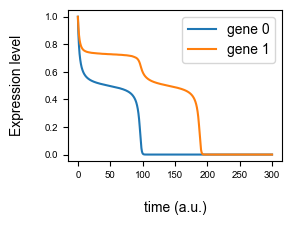

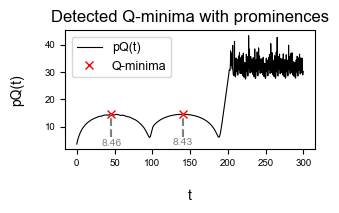

270 329 598


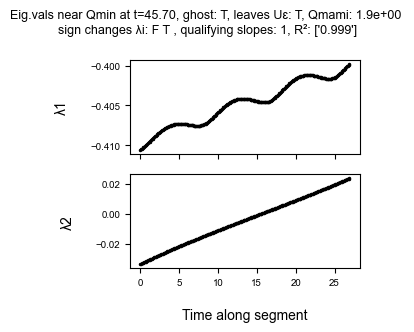

280 1261 1540


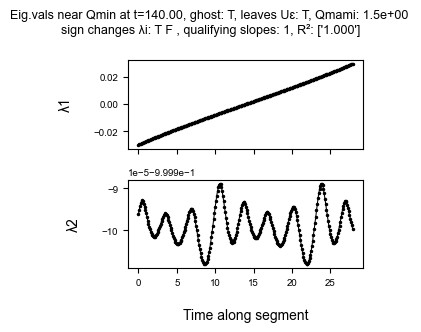

In [2]:
A = np.array([[0,0],[1,0]])
parameters_GRN_net = [0.998,0.1,0.5,0.5,0.5,A]
dt = 0.1
t_end=300
timesteps = np.linspace(0,t_end,int(t_end/dt))

sol = solve_ivp(mod.GRN_net, (0, t_end), [1,1],
                        t_eval=timesteps, args=(parameters_GRN_net,),method='RK45')

fig = plt.figure(figsize=(7*inCm,5*inCm))
for ii in range(2):
    plt.plot(sol.t,sol.y[ii,:],label=f"gene {ii}")
plt.legend()
plt.xlabel("time (a.u.)")
plt.ylabel("Expression level")

Trj=sol.y.T
ghostSeqs = gid.ghostID(mod.GRN_net,parameters_GRN_net,dt,Trj,0.015,peak_kwargs={"prominence":2,"width":50*dt},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":False},evLimit=0.03)